In [3]:
# Load libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys

%load_ext autoreload
%autoreload 2

# Import load_csv
sys.path.append("project")
from helpers import load_csv_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Position us in the uppest directory
x_train, x_test, y_train, train_ids, test_ids = load_csv_data('data/dataset')

In [5]:
# Dataset shape without using pandas
print("Train set shape : ", x_train.shape)
print("Test set shape : ", x_test.shape)

Train set shape :  (328135, 321)
Test set shape :  (109379, 321)


In [6]:
# Number of lines that contain NaN values in train set
count_rows_with_nan = np.sum(np.isnan(x_train).any(axis=1))
print("Number of rows containing at least one NaN in train set:", count_rows_with_nan)

# Number of columns that contain NaN values in train set
count_columns_with_nan = np.sum(np.isnan(x_train).any(axis=0))
print("Number of columns containing at least one NaN in train set:", count_columns_with_nan)

# Number of lines that contain NaN values in test set
count_rows_with_nan = np.sum(np.isnan(x_test).any(axis=1))
print("Number of rows containing at least one NaN in test set:", count_rows_with_nan)

# Number of columns that contain NaN values in test set
count_columns_with_nan = np.sum(np.isnan(x_test).any(axis=0))
print("Number of columns containing at least one NaN in test set:", count_columns_with_nan)

Number of rows containing at least one NaN in train set: 328135
Number of columns containing at least one NaN in train set: 239
Number of rows containing at least one NaN in test set: 109379
Number of columns containing at least one NaN in test set: 232


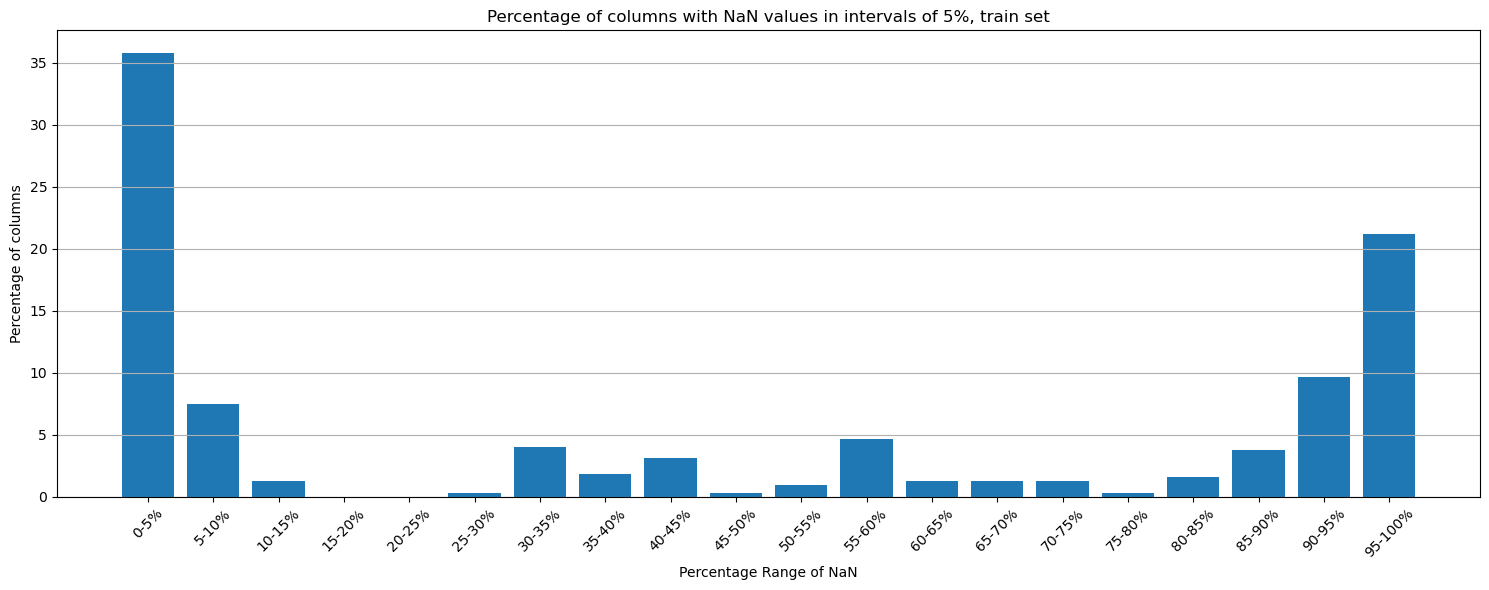

In [7]:
# Liste de percentiles à examiner (de 0 à 100 par pas de 5)
percentiles = list(range(0, 101, 5))

# Calcul du pourcentage des colonnes ayant un pourcentage de NaN entre x% et (x+5)%
percentage_columns_with_percentile_nans = [
    (np.isnan(x_train).sum(axis=0)[
        (np.isnan(x_train).sum(axis=0) >= x_train.shape[0]*p/100) &
        (np.isnan(x_train).sum(axis=0) < x_train.shape[0]*(p+5)/100)
    ].shape[0] / x_train.shape[1]) * 100 for p in percentiles[:-1]  # Exclude the last percentile (100%)
]

# Labels for the x-axis
percentile_labels = [f'{p}-{p+5}%' for p in percentiles[:-1]]

# Affichage du graphique
plt.figure(figsize=(15, 6))
plt.bar(percentile_labels, percentage_columns_with_percentile_nans)

plt.title('Percentage of columns with NaN values in intervals of 5%, train set')
plt.xlabel('Percentage Range of NaN')
plt.ylabel('Percentage of columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

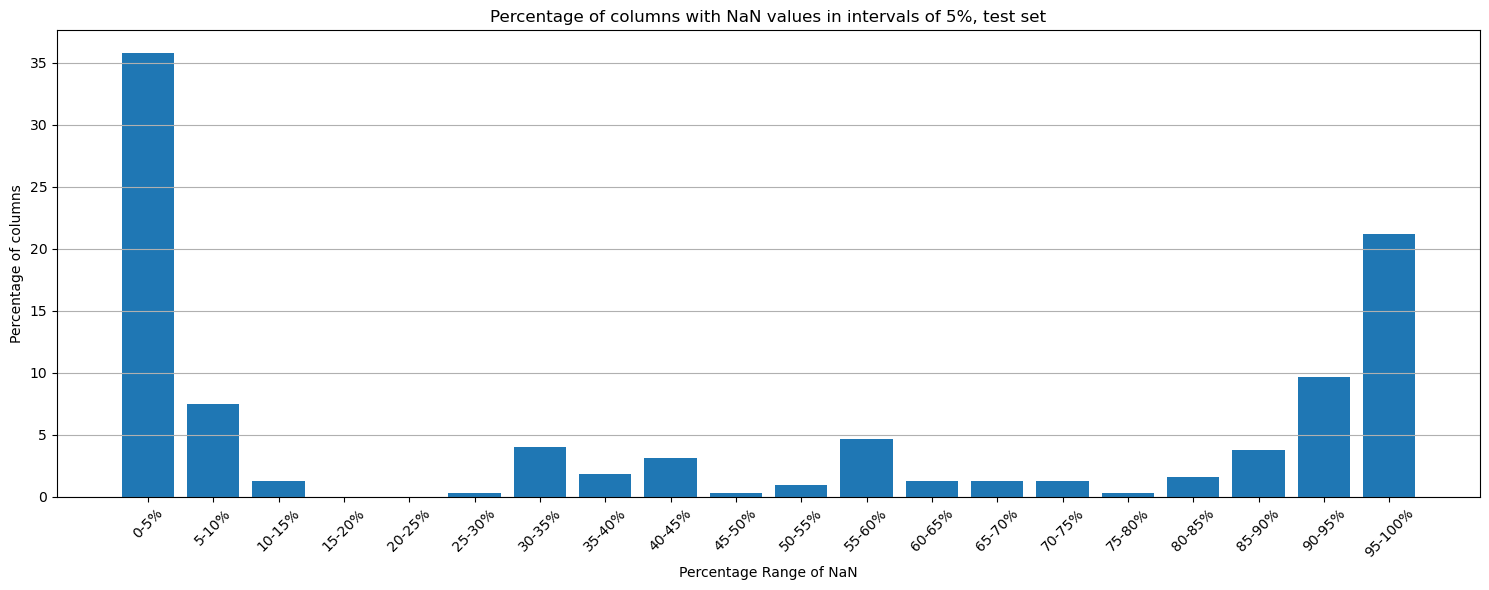

In [8]:
# Calcul du pourcentage des colonnes ayant un pourcentage de NaN entre x% et (x+5)%
percentage_columns_with_percentile_nans = [
    (np.isnan(x_test).sum(axis=0)[
        (np.isnan(x_test).sum(axis=0) >= x_test.shape[0]*p/100) &
        (np.isnan(x_test).sum(axis=0) < x_test.shape[0]*(p+5)/100)
    ].shape[0] / x_test.shape[1]) * 100 for p in percentiles[:-1]  # Exclude the last percentile (100%)
]

# Labels for the x-axis
percentile_labels = [f'{p}-{p+5}%' for p in percentiles[:-1]]

# Affichage du graphique
plt.figure(figsize=(15, 6))
plt.bar(percentile_labels, percentage_columns_with_percentile_nans)

plt.title('Percentage of columns with NaN values in intervals of 5%, test set')
plt.xlabel('Percentage Range of NaN')
plt.ylabel('Percentage of columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()